<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-07 08:37:44--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.2’

survey-results-publ 100%[===================>] 201.62M  37.6MB/s    in 5.7s    

2026-07-07 08:37:52 (35.3 MB/s) - ‘survey-results-public.sqlite.2’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


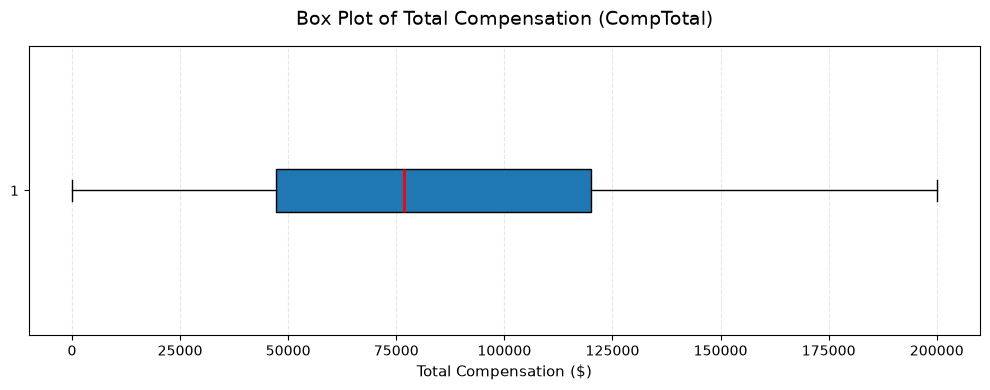

In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and read CompTotal
conn = sqlite3.connect("survey-data.sqlite")
df_box1 = pd.read_sql_query("SELECT CompTotal FROM main", conn)
conn.close()

# 2. Convert to numeric and drop missing records
df_box1['CompTotal'] = pd.to_numeric(df_box1['CompTotal'], errors='coerce')
df_box1 = df_box1.dropna(subset=['CompTotal'])

# 3. Filter out extreme corrupt outliers (keeping values up to $200k for clean scaling)
df_filtered = df_box1[df_box1['CompTotal'] <= 200000]

# 4. Plot a horizontal box plot using the updated orientation parameter
plt.figure(figsize=(10, 4))
plt.boxplot(df_filtered['CompTotal'], orientation='horizontal', patch_artist=True,
            boxprops=dict(facecolor='#1f77b4', color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Box Plot of Total Compensation (CompTotal)', fontsize=14, pad=15)
plt.xlabel('Total Compensation ($)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


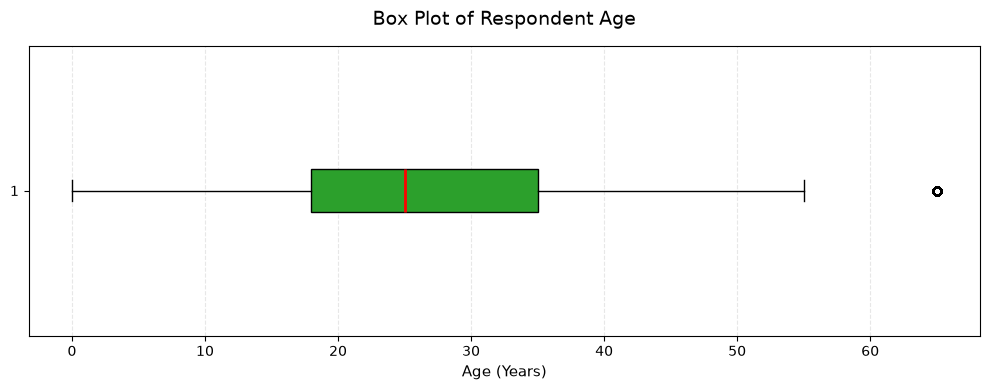

In [14]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and cleanly query Age as a number using CAST
conn = sqlite3.connect("survey-data.sqlite")
query = "SELECT CAST(Age AS REAL) AS Age FROM main"
df_box2 = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop any missing or null records
df_box2 = df_box2.dropna(subset=['Age'])

# 3. Plot a horizontal box plot for Age
plt.figure(figsize=(10, 4))
plt.boxplot(df_box2['Age'], orientation='horizontal', patch_artist=True,
            boxprops=dict(facecolor='#2ca02c', color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Box Plot of Respondent Age', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


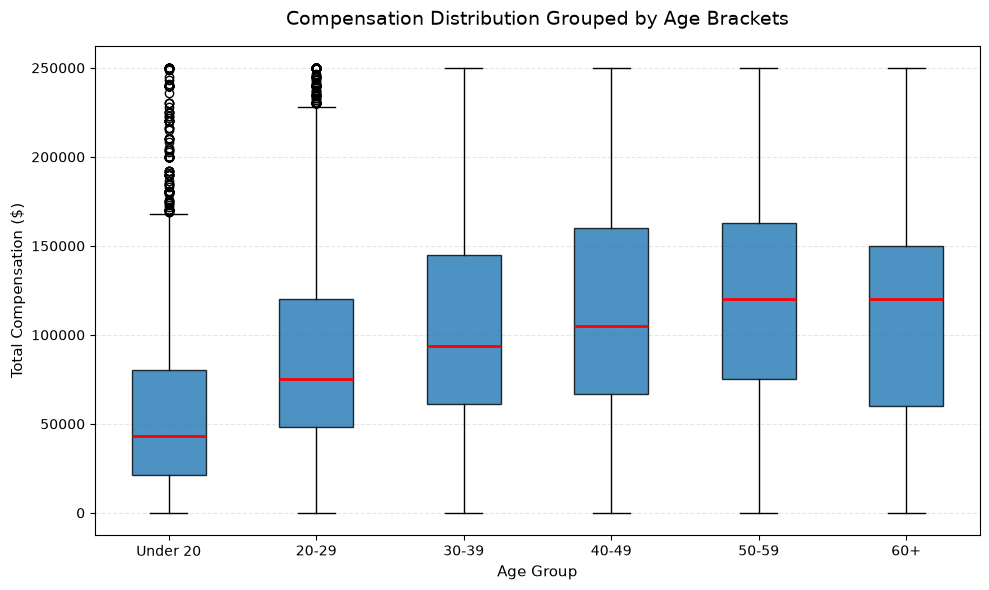

In [16]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query Age and CompTotal
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(Age AS REAL) AS Age,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
"""
df_grouped = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean up missing records and filter out extreme salary outliers for clean scaling
df_grouped = df_grouped.dropna(subset=['Age', 'CompTotal'])
df_filtered = df_grouped[df_grouped['CompTotal'] <= 250000]

# 3. Bin the ages into clean 10-year generation groups
bins = [0, 19, 29, 39, 49, 59, 100]
labels = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60+']
df_filtered['AgeGroup'] = pd.cut(df_filtered['Age'], bins=bins, labels=labels)

# 4. Extract data arrays for each age group to plot
plot_data = [df_filtered[df_filtered['AgeGroup'] == label]['CompTotal'] for label in labels]

# 5. Plot the side-by-side vertical box plots using the correct tick_labels parameter
plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, tick_labels=labels, patch_artist=True,
            boxprops=dict(facecolor='#1f77b4', color='black', alpha=0.8),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Compensation Distribution Grouped by Age Brackets', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Compensation ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


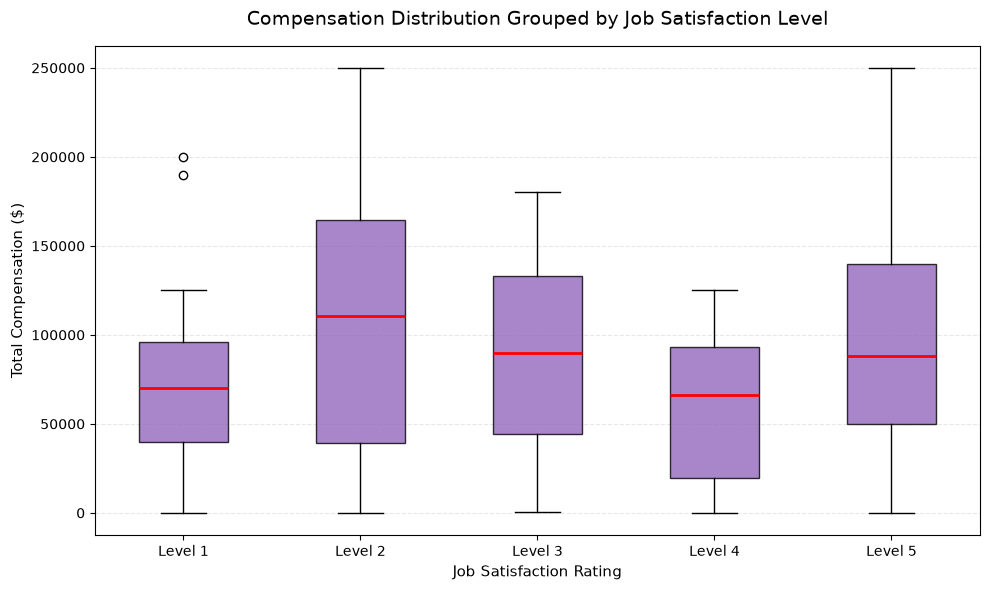

In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query JobSatPoints_6 and CompTotal
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    CAST(JobSatPoints_6 AS REAL) AS JobSatPoints,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
"""
df_sat = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop missing records and filter out extreme salary outliers
df_sat = df_sat.dropna(subset=['JobSatPoints', 'CompTotal'])
df_filtered = df_sat[df_sat['CompTotal'] <= 250000]

# 3. Round or convert JobSatPoints to clean, whole integers (1 through 5)
df_filtered['JobSatPoints'] = df_filtered['JobSatPoints'].round().astype(int)
# Keep only standard survey levels 1 to 5
df_filtered = df_filtered[df_filtered['JobSatPoints'].between(1, 5)]

# 4. Group data cleanly by individual satisfaction levels
sat_levels = sorted(df_filtered['JobSatPoints'].unique())
plot_data = [df_filtered[df_filtered['JobSatPoints'] == level]['CompTotal'] for level in sat_levels]

# 5. Plot 5 distinct, beautiful side-by-side box plots
plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, tick_labels=[f'Level {l}' for l in sat_levels], patch_artist=True,
            boxprops=dict(facecolor='#9467bd', color='black', alpha=0.8),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Compensation Distribution Grouped by Job Satisfaction Level', fontsize=14, pad=15)
plt.xlabel('Job Satisfaction Rating', fontsize=11)
plt.ylabel('Total Compensation ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


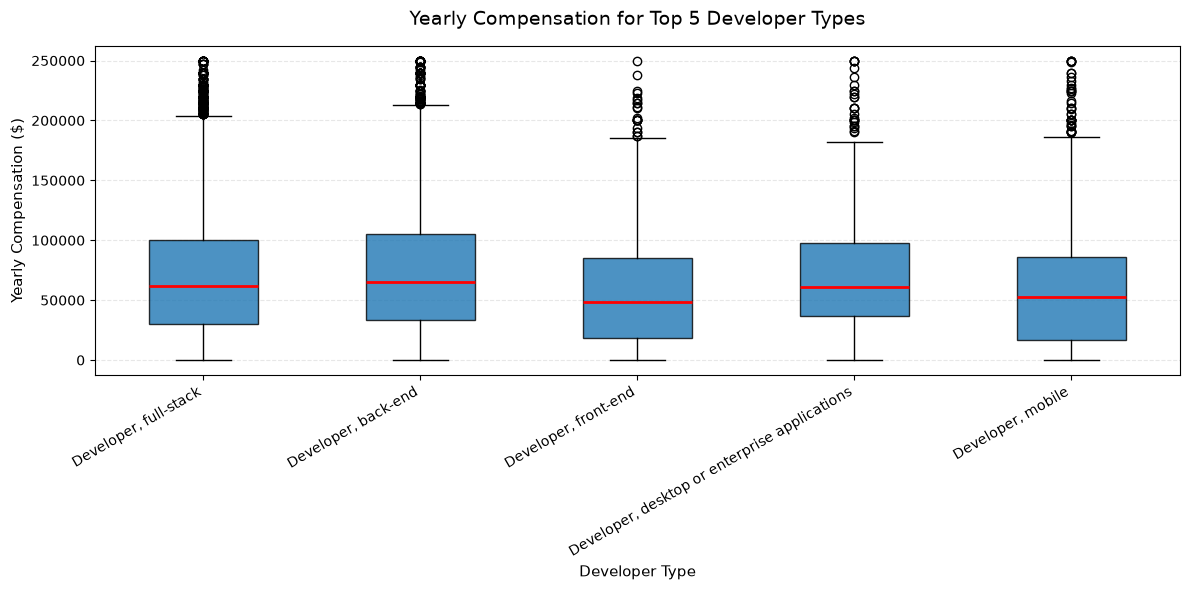

In [20]:
# your code goes here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query DevType and ConvertedCompYearly
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    DevType,
    CAST(ConvertedCompYearly AS REAL) AS ConvertedCompYearly
FROM main
"""
df_comp = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean missing data and filter out extreme salary outliers
df_comp = df_comp.dropna(subset=['DevType', 'ConvertedCompYearly'])
df_filtered = df_comp[df_comp['ConvertedCompYearly'] <= 250000]

# 3. Identify the Top 5 Developer Types by respondent count
top_5_devs = df_filtered['DevType'].value_counts().nlargest(5).index.tolist()

# 4. Filter dataset for only these top 5 types
df_top_5 = df_filtered[df_filtered['DevType'].isin(top_5_devs)]

# 5. Group the compensation data for plotting
plot_data = [df_top_5[df_top_5['DevType'] == dev]['ConvertedCompYearly'] for dev in top_5_devs]

# 6. Plot side-by-side vertical box plots
plt.figure(figsize=(12, 6))
plt.boxplot(plot_data, tick_labels=top_5_devs, patch_artist=True,
            boxprops=dict(facecolor='#1f77b4', color='black', alpha=0.8),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Yearly Compensation for Top 5 Developer Types', fontsize=14, pad=15)
plt.xlabel('Developer Type', fontsize=11)
plt.ylabel('Yearly Compensation ($)', fontsize=11)
plt.xticks(rotation=30, ha='right') # Rotate long developer names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


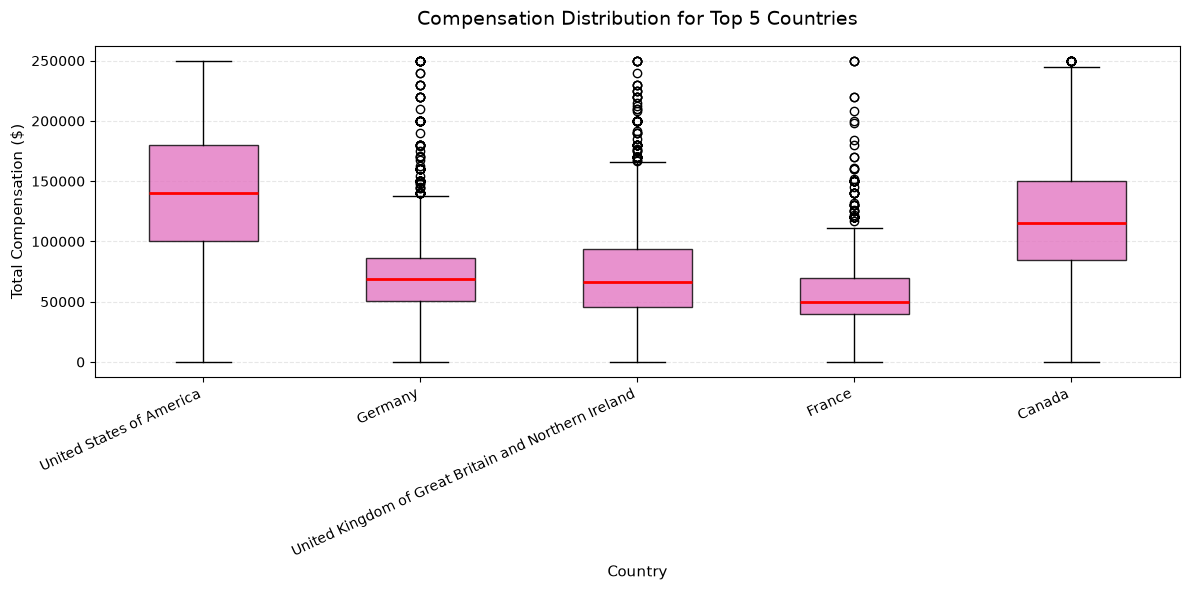

In [21]:
# your code goes here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query Country and CompTotal
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    Country,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
"""
df_country = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean missing data and filter out extreme salary outliers
df_country = df_country.dropna(subset=['Country', 'CompTotal'])
df_filtered = df_country[df_country['CompTotal'] <= 250000]

# 3. Identify the Top 5 Countries by respondent count
top_5_countries = df_filtered['Country'].value_counts().nlargest(5).index.tolist()

# 4. Filter dataset for only these top 5 countries
df_top_5 = df_filtered[df_filtered['Country'].isin(top_5_countries)]

# 5. Group the compensation data for plotting
plot_data = [df_top_5[df_top_5['Country'] == country]['CompTotal'] for country in top_5_countries]

# 6. Plot side-by-side vertical box plots using tick_labels
plt.figure(figsize=(12, 6))
plt.boxplot(plot_data, tick_labels=top_5_countries, patch_artist=True,
            boxprops=dict(facecolor='#e377c2', color='black', alpha=0.8),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Compensation Distribution for Top 5 Countries', fontsize=14, pad=15)
plt.xlabel('Country', fontsize=11)
plt.ylabel('Total Compensation ($)', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


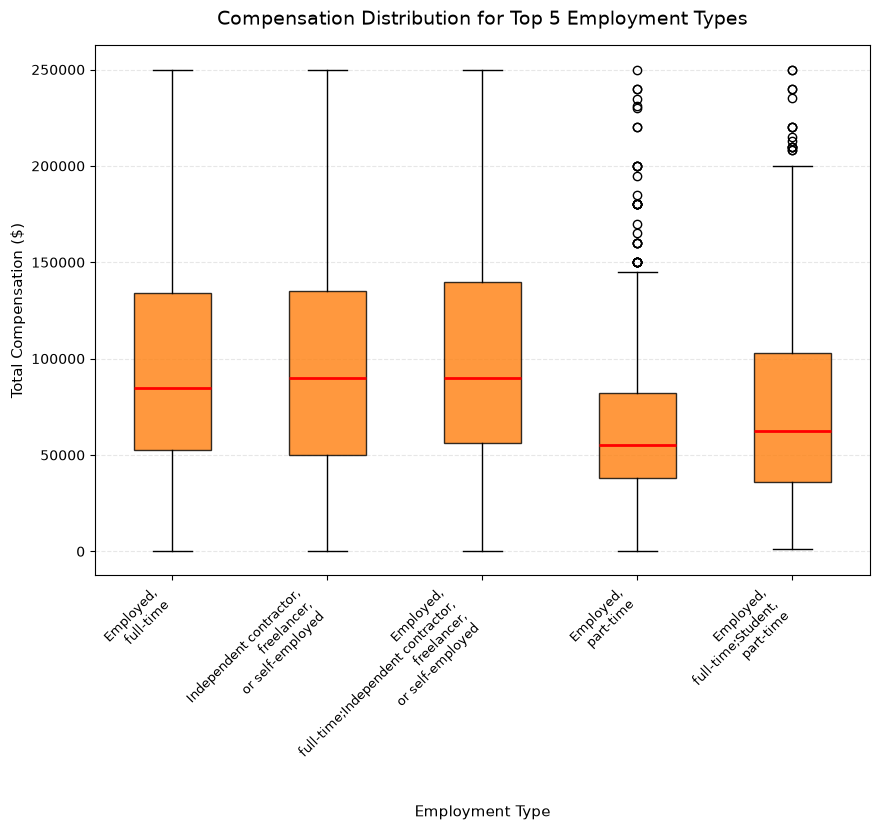

In [32]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query Employment and CompTotal
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    Employment,
    CAST(CompTotal AS REAL) AS CompTotal
FROM main
"""
df_emp = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean missing data and filter out extreme salary outliers
df_emp = df_emp.dropna(subset=['Employment', 'CompTotal'])
df_filtered = df_emp[df_emp['CompTotal'] <= 250000]

# 3. Identify the Top 5 Employment types by count to get rid of the messy columns
top_5_emp = df_filtered['Employment'].value_counts().nlargest(5).index.tolist()
df_top_5 = df_filtered[df_filtered['Employment'].isin(top_5_emp)]

# 4. Group the compensation data cleanly for just these top 5 types
plot_data = [df_top_5[df_top_5['Employment'] == emp]['CompTotal'] for emp in top_5_emp]

# 5. Shorten/wrap the labels slightly so they stack neatly without spilling over
wrapped_labels = [emp.replace(', ', ',\n').replace(' or ', '\nor\n') for emp in top_5_emp]

# 6. Plot the 5 vertical box plots with a taller canvas
fig, ax = plt.subplots(figsize=(10, 10))
ax.boxplot(plot_data, tick_labels=wrapped_labels, patch_artist=True,
           boxprops=dict(facecolor='#ff7f0e', color='black', alpha=0.8),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Compensation Distribution for Top 5 Employment Types', fontsize=14, pad=15)
plt.ylabel('Total Compensation ($)', fontsize=11)
plt.xlabel('Employment Type', fontsize=11, labelpad=15)

# Rotate 45 degrees so they stream neatly downward without being cut off
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Dedicate space at the bottom for the labels
plt.subplots_adjust(bottom=0.35)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


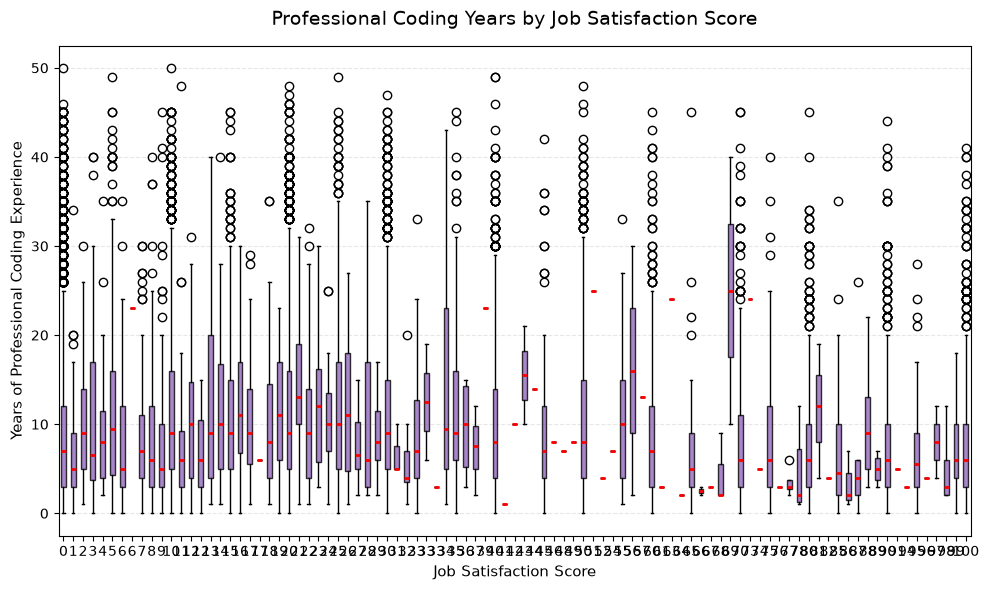

In [33]:
# your code goes here
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect to the database and query JobSatPoints_6 and YearsCodePro
conn = sqlite3.connect("survey-data.sqlite")
query = """
SELECT 
    JobSatPoints_6,
    CAST(YearsCodePro AS REAL) AS YearsCodePro
FROM main
"""
df_sat = pd.read_sql_query(query, conn)
conn.close()

# 2. Drop rows with missing values
df_sat = df_sat.dropna(subset=['JobSatPoints_6', 'YearsCodePro'])

# 3. Sort satisfaction categories so they line up sequentially (e.g., 1.0 to 5.0)
sat_scores = sorted(df_sat['JobSatPoints_6'].unique())

# 4. Group professional coding years for plotting
plot_data = [df_sat[df_sat['JobSatPoints_6'] == score]['YearsCodePro'] for score in sat_scores]

# 5. Plot side-by-side vertical box plots using the correct tick_labels parameter
plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, tick_labels=[str(int(score)) for score in sat_scores], patch_artist=True,
            boxprops=dict(facecolor='#9467bd', color='black', alpha=0.8),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Professional Coding Years by Job Satisfaction Score', fontsize=14, pad=15)
plt.xlabel('Job Satisfaction Score', fontsize=11)
plt.ylabel('Years of Professional Coding Experience', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [34]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
